In [1]:
import sys
import os
current_dir = os.getcwd()

import cProfile
import pstats
sys.path.append('/home/dxie/myPy/VEBGLM/src')
# Get the parent directory
parent_dir = os.path.dirname(current_dir)

# Add the parent directory to the system path
sys.path.append(parent_dir)
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from VEBGLM import VEBGLM
from prior import HorseshoePrior
from methods.bayesregR import bayesregR
from methods.glmnetR import glmnetR
from methods.glmnetR import elasticnetR
from methods.L0Learn import L0Learn
from methods.ncvregR import ncvregR
from methods.sparsevbR import sparsevbR
from methods.varbvsR import varbvsR
import argparse
import pickle
import torch
import matplotlib.pyplot as plt 


# Define data generation methods
def generate_train_data(n, p, r, beta, X_generator):
    X = X_generator(n, p, r)
    y = np.random.binomial(1, 1 / (1 + np.exp(-X @ beta)))
    return X, y

def generate_test_data(n_test,p,r,beta,X_generator):
    X = X_generator(n_test, p, r,scale_by_n=False)
    y = np.random.binomial(1, 1 / (1 + np.exp(-X @ beta)))
    return X,y

def X_generator(n, p, r, scale_by_n=False):
    if r == 0.0:
        if scale_by_n:
            return np.random.normal(0, np.sqrt(1/n), (n, p))
        else:
            return np.random.normal(0, 1, (n, p))
    else:
        if scale_by_n:
            return np.random.multivariate_normal(np.zeros(p), gen_cov(p,r)/n, n)
        else:
            return np.random.multivariate_normal(np.zeros(p), gen_cov(p,r), n)

def gen_cov(p,r):
    res = np.zeros((p,p))
    for i in range(p):
        for j in range(p):
            res[i,j] = r**np.abs(j-i)
    return res
def gen_beta_normal(p,s):
    beta = np.zeros((p,1))
    beta[0:s,:] = np.random.randn(s,1)
    return beta
def gen_beta_laplace(p,s):
    beta = np.zeros((p,1))
    beta[0:s,:] = np.random.laplace(size=(s,1))
    return beta
def gen_beta_t(p,s,df=1):
    beta = np.zeros((p,1))
    beta[0:s,:] = np.random.standard_t(df=df,size=(s,1))
    return beta
def gen_beta_uniform(p,s):
    beta = np.zeros((p,1))
    beta[0:s,:] = np.random.uniform(-1,1,size=(s,1))
    return beta
def gen_beta_constant(n,p,r,s,const=1,target_var = None,sign='-'):
    """generate beta such that var(Xb) = 5"""
    X = X_generator(n, p, r)
    beta = np.zeros((p,1))
    if sign=="+":
        beta[0:int(s),:] = const
    elif sign=="-":
        beta[0:int(s),:] = -const
    else:
        beta[0:int(s/2),:] = const
        beta[int(s/2):s,:] = -const
    if target_var:
        beta = beta * np.sqrt(target_var / np.var(X@beta))
    return beta

/home/dxie/anaconda3/envs/misc10/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
import numpy as np
import rpy2.robjects as ro
from rpy2.robjects import r,numpy2ri
from rpy2.robjects.packages import importr
import rpy2.robjects.packages as rpackages

# Utility function to check for missing packages and install them
def install_missing_r_packages(package_names):
    utils = rpackages.importr('utils')
    utils.chooseCRANmirror(ind=1)
    for package_name in package_names:
        if not rpackages.isinstalled(package_name):
            utils.install_packages(package_name)

In [3]:
import numpy as np
import rpy2.robjects as ro
from rpy2.robjects import r,numpy2ri, NULL, pandas2ri
from rpy2.robjects.packages import importr
import torch
import pandas as pd

def get_posterior(vebglm):
    ebnm = importr('ebnm')
    ashr = importr('ashr')
    numpy2ri.activate()
    pandas2ri.activate()
    mu = torch.matmul(vebglm.X,vebglm.beta) + vebglm.intercept
    s2 = vebglm.lik.s2(vebglm.X2,mu,vebglm.phi,vebglm.sum_X2).squeeze()
    z = vebglm._get_z(s2)
    s2 = s2.detach().numpy()
    z = z.detach().numpy()
    # run ebnm to get the posterior
    if vebglm.prior.prior_name == 'ash':
        w = vebglm.prior.w.detach().numpy()
        sigma = vebglm.prior.sigma.detach().numpy()
        r_code = """
        library(ebnm)
        library(ashr)
        ff = ebnm::ebnm(x=x, s=sqrt(s2), prior_family = 'normal_scale_mixture', g_init = ashr::normalmix(w, rep(0, K), sigma), fix_g = TRUE,output=ebnm_output_all())
        """
        ro.globalenv['x'] = ro.FloatVector(z)  # Example values
        ro.globalenv['s2'] = ro.FloatVector(s2)  # Example values
        ro.globalenv['w'] = ro.FloatVector(w)  # Example weights
        ro.globalenv['K'] = ro.IntVector([vebglm.prior.K.numpy()])  # Number of components
        ro.globalenv['sigma'] = ro.FloatVector(sigma)  # Standard deviations
        ro.r(r_code)
        ff = ro.globalenv['ff']
        ff_posterior = ff.rx2('posterior')
        with (ro.default_converter + pandas2ri.converter).context():
            pd_from_r_df = ro.conversion.get_conversion().rpy2py(ff_posterior)
        return pd_from_r_df
    elif vebglm.prior.prior_name == 'point_normal':
        w = vebglm.prior.w.squeeze().detach().numpy()
        sigma = vebglm.prior.sigma.squeeze().detach().numpy()
        r_code = """
        library(ebnm)
        library(ashr)
        ff = ebnm::ebnm(x=x, s=sqrt(s2), prior_family = 'normal_scale_mixture', g_init = ashr::normalmix(w, c(0,0), c(0,sigma)), fix_g = TRUE,output=ebnm_output_all())
        """
        ro.globalenv['x'] = ro.FloatVector(z)  # Example values
        ro.globalenv['s2'] = ro.FloatVector(s2)  # Example values
        ro.globalenv['w'] = ro.FloatVector(w)  # Example weights
        ro.globalenv['sigma'] = ro.FloatVector(sigma)  # Standard deviations
        ro.r(r_code)
        ff = ro.globalenv['ff']
        ff_posterior = ff.rx2('posterior')
        with (ro.default_converter + pandas2ri.converter).context():
            pd_from_r_df = ro.conversion.get_conversion().rpy2py(ff_posterior)
        return pd_from_r_df
    elif vebglm.prior.prior_name == 'point_laplace':
        w = vebglm.prior.w.squeeze().detach().numpy()
        sigma = vebglm.prior.sigma.squeeze().detach().numpy()
        r_code = """
        library(ebnm)
        library(ashr)
        ff = ebnm::ebnm(x=x, s=sqrt(s2), prior_family = 'point_laplace',g_init = laplacemix(w,c(0,0),c(0,sigma)),fix_g = TRUE,output=ebnm_output_all())
        """
        ro.globalenv['x'] = ro.FloatVector(z)  # Example values
        ro.globalenv['s2'] = ro.FloatVector(s2)  # Example values
        ro.globalenv['w'] = ro.FloatVector(w)  # Example weights
        ro.globalenv['sigma'] = ro.FloatVector(sigma)  # Standard deviations
        ro.r(r_code)
        ff = ro.globalenv['ff']
        ff_posterior = ff.rx2('posterior')
        with (ro.default_converter + pandas2ri.converter).context():
            pd_from_r_df = ro.conversion.get_conversion().rpy2py(ff_posterior)
        return pd_from_r_df
    else:
        raise ValueError('Only support ash, point_normal, and point_laplace priors.')


In [4]:

def ploter(beta_est,beta_true):
    p = len(beta_est.squeeze())
    plt.figure(figsize=(10, 6))
    plt.scatter(range(p), beta_est)
    plt.plot(range(p),beta_true)
    plt.xlabel('Coefficient Index')
    plt.ylabel('Coefficient Value')
    plt.title('Fitted Coefficients')
    plt.show()

def ploter_lfsr(lfsr):
    p = len(lfsr)
    plt.figure(figsize=(10, 6))
    plt.scatter(range(p),lfsr)
    plt.xlabel('Coefficient Index')
    plt.ylabel('lfsr')
    plt.show()

def fitting(model,X_train,X_test,y_train,y_test,beta_true):
    # model = VEBLR(tol=1e-8,solver='lbfgs',prior='ash')
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_prob(X_test)
    print(roc_auc_score(y_test, y_prob))
    ploter(model.beta.detach().numpy(),beta_true)

In [5]:
n = 500
p = 100
r = 0.0
s = 5
target_var = 6

In [6]:
np.random.seed(12345)
# beta = gen_beta_constant(n,p,r,s,target_var,sign='+')
#beta = gen_beta_laplace(p,s)
# beta = gen_beta_uniform(p,s)
# beta = gen_beta_t(p,s)
beta = gen_beta_normal(p,s)
X_train, y_train = generate_train_data(n, p, r, beta, X_generator)
X_test, y_test = generate_test_data(3000, p, r,beta, X_generator)
beta[0:s,:]

array([[-0.20470766],
       [ 0.47894334],
       [-0.51943872],
       [-0.5557303 ],
       [ 1.96578057]])

In [7]:
# from sklearn.datasets import make_classification
# from sklearn.model_selection import train_test_split
# X,y = make_classification(n_samples=3000,n_features=500,n_informative=10,class_sep = 0.6)

In [8]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=5/6)

In [9]:
model = VEBGLM(tol=1e-5,solver='lbfgs',prior='ash',verbose=True,printevery=100)
model.fit(X_train,y_train,beta_init=None)
y_pred = model.predict(X_test)
y_prob = model.predict_prob(X_test)
roc_auc_score(y_test, y_prob)

Initializing using lasso
Initialization done in 1.2 seconds
Initial loss is 259.14
Training model using lbfgs
Training done in 2.0 seconds
Total training time is 3.2 seconds
Final loss is 251.59


0.8590392372570592

In [10]:
model.prior.sigma

tensor([0.0000e+00, 1.0000e-02, 1.5007e-02, 2.2520e-02, 3.3796e-02, 5.0717e-02,
        7.6110e-02, 1.1422e-01, 1.7140e-01, 2.5722e-01, 3.8601e-01, 5.7928e-01,
        8.6931e-01, 1.3046e+00, 1.9577e+00, 2.9379e+00, 4.4089e+00, 6.6164e+00,
        9.9290e+00, 1.4900e+01, 2.2361e+01], dtype=torch.float64)

In [11]:
np.sqrt(np.mean((model.beta.detach().numpy() - beta)**2))

0.2871773931330533

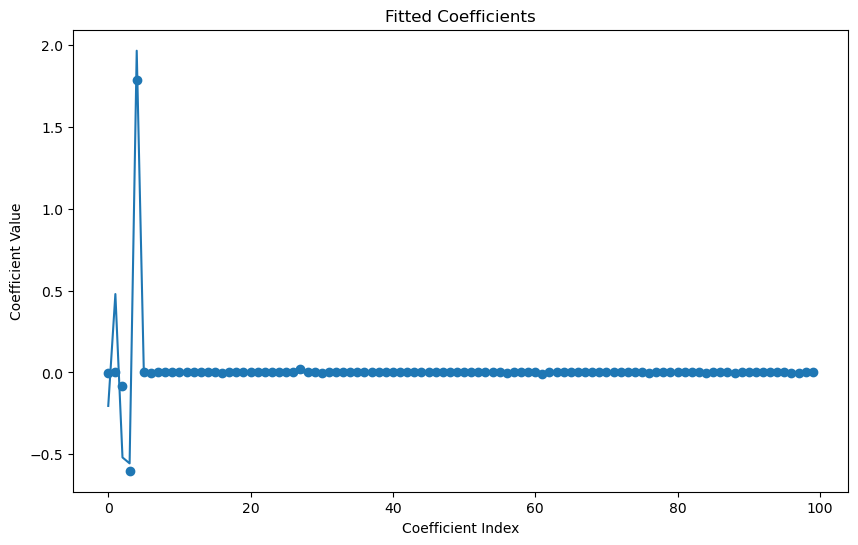

In [12]:
ploter(model.beta.detach().numpy()[0:100],beta[0:100])

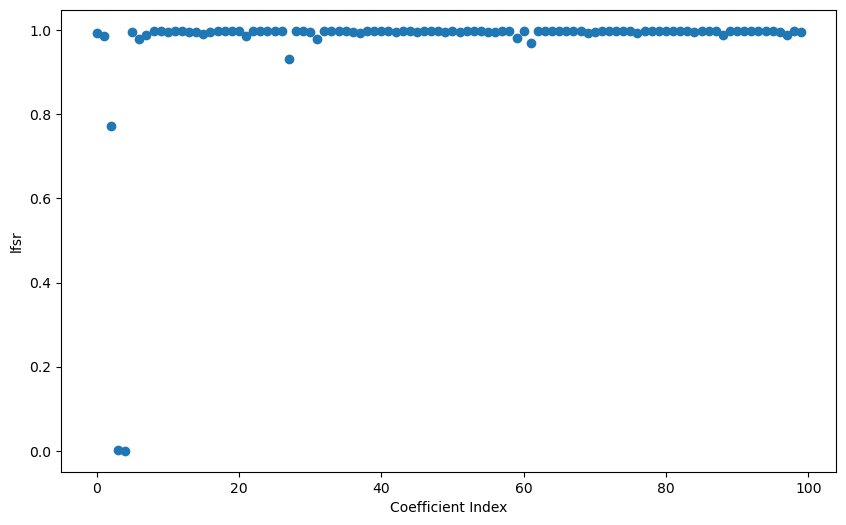

In [13]:
ploter_lfsr(model.get_posterior()['lfsr'][0:100])

In [71]:
model.prior.K

21

In [56]:
model.prior.w

tensor([[0.9706, 0.0294]], grad_fn=<UnsqueezeBackward0>)

In [27]:
model = bayesregR(prior='hs')
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_prob(X_test)
roc_auc_score(y_test, y_prob)

0.9092403248924988

In [57]:
model = glmnetR()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_prob(X_test)
roc_auc_score(y_test, y_prob)


0.8576617661766176

In [58]:
np.sqrt(np.mean((model.beta - beta)**2))

0.2542023950437885

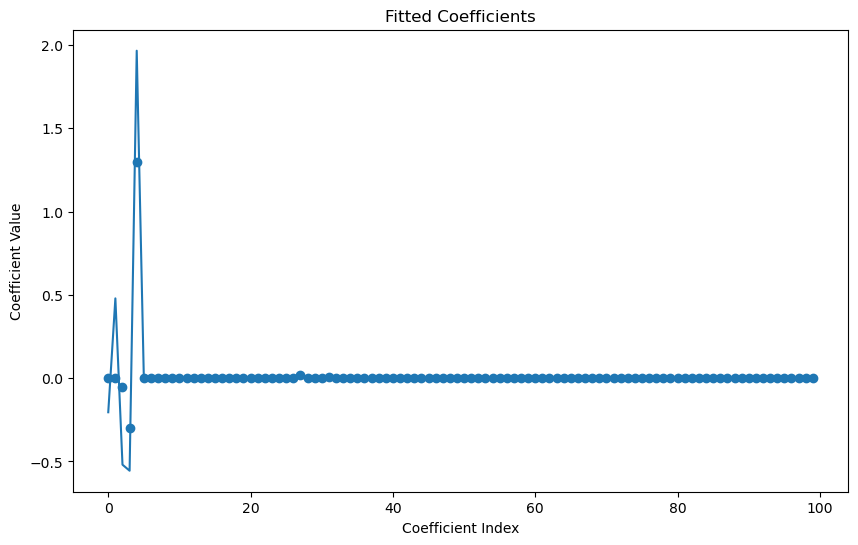

In [59]:
ploter(model.beta[0:100],beta[0:100])

In [35]:
model = elasticnetR()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_prob(X_test)
roc_auc_score(y_test, y_prob)

0.8355534317211948

In [36]:
np.sqrt(np.mean((model.beta - beta)**2))

0.13435688527622613

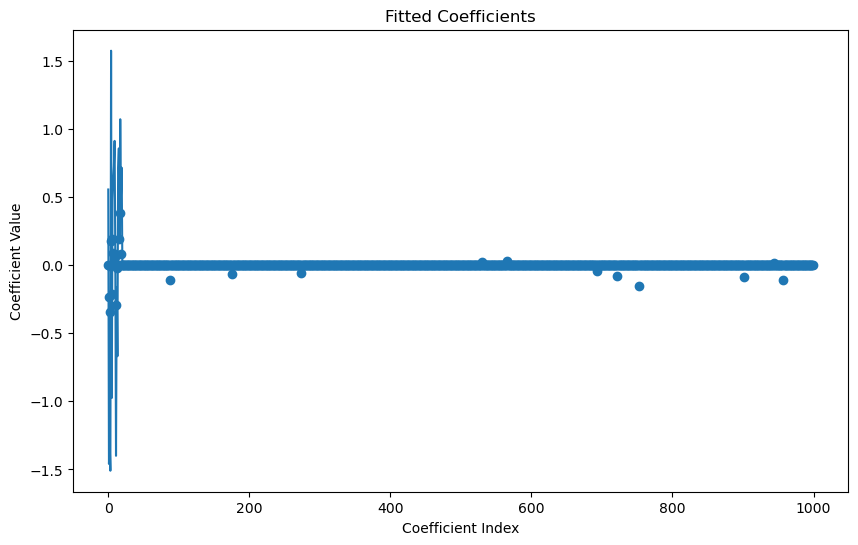

In [37]:
ploter(model.beta,beta)

In [60]:
model = varbvsR()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_prob(X_test)
roc_auc_score(y_test, y_prob)

0.8559353713149094

In [61]:
np.sqrt(np.mean((model.beta - beta)**2))

0.28414127624155

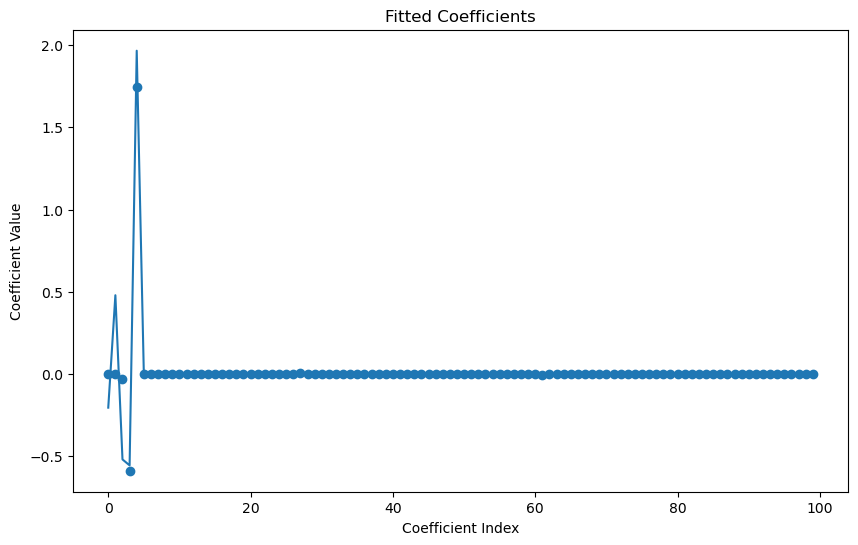

In [62]:
ploter(model.beta[0:100],beta[0:100])

In [63]:
model = ncvregR()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_prob(X_test)
roc_auc_score(y_test, y_prob)

0.8663292995966263

In [64]:
np.sqrt(np.mean((model.beta - beta)**2))

0.29454053937498337

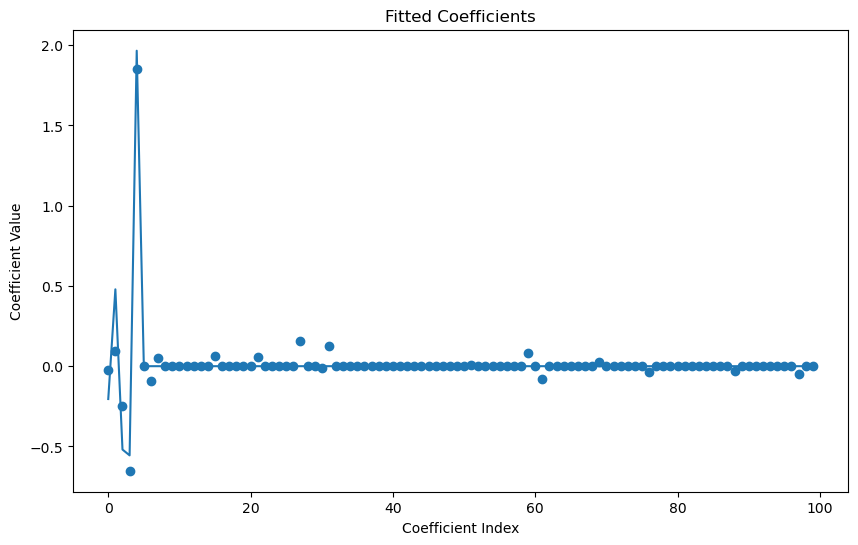

In [65]:
ploter(model.beta[0:100],beta[0:100])

In [6]:
model = bayesregR()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_prob(X_test)
roc_auc_score(y_test, y_prob)

R[write to console]: Error in (function (formula, data, model = "normal", prior = "ridge",  : 
  Target variable must be a factor with two levels for logistic regression



RRuntimeError: Error in (function (formula, data, model = "normal", prior = "ridge",  : 
  Target variable must be a factor with two levels for logistic regression


In [2]:
import pickle 
with open('/home/dxie/myPy/VBLR/simu_data2.pkl', 'rb') as f:
    datax = pickle.load(f)

In [5]:
X=datax[-1]['X_train']
y=datax[-1]['y_train']
X_test = datax[-1]['X_test']
y_test=datax[-1]['y_test']

In [27]:
model = ncvregR()
model.fit(X,y)
y_pred = model.predict(X_test)
y_prob = model.predict_prob(X_test)
roc_auc_score(y_test, y_prob)

37
37


0.775773915362731

In [259]:
type(model).__name__

'varbvsR'

In [261]:
if model.prior.name:
    print(1)
else:
    print(0)

AttributeError: 'varbvsR' object has no attribute 'prior'